In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
import pandas as pd

In [3]:
# defining class and its labels
classes = {'no_tumor': 0, 'pituitary_tumor': 1, 'glioma_tumor': 2, 'meningioma_tumor': 3}

#loads and preprocesses the data
X = [] #stores images
Y = [] #stores labels

for cls, label in classes.items():
    pth = f"C:/Users/Tanishk/Desktop/Medical-Image-Classification/data/brain/Training/{cls}"

    for filename in os.listdir(pth): #returns all files in the folder, basically looping through all the images
        img = cv2.imread(os.path.join(pth, filename), 0) #reads the path of the image and converts it to grayscale
        img = cv2.resize(img, (200, 200)) #makes all the images same size
        X.append(img.flatten() / 255.0) # flattens and normalizes the image and adds it to X
        Y.append(label)

X = np.array(X) #2870, 40000
Y = np.array(Y) #2870,

In [4]:
#splitting the data into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X, Y,
    random_state=10, #produces the same random split every time
    test_size=0.8 #80% data is used for testing
)

#reduces dimensionality 
pca = PCA(n_components=0.98) #keeps 98% of data variance

pca_train = pca.fit_transform(xtrain) #fits the PCA model to the training data and transforms it, reducing its dimensionality
pca_test = pca.transform(xtest) #transforms the test data using the same PCA model fitted on the training data, ensuring that both datasets are reduced to the same number of dimensions

#trains the support vector classifier
sv = SVC(kernel="rbf")
sv.fit(pca_train, ytrain) #which pattern corresponds to which label
train_score = sv.score(pca_train, ytrain) #accuracy of the model on the training data
test_score = sv.score(pca_test, ytest) #accuracy of the model on the test data (unseen data)

print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 0.9407665505226481
Testing Score: 0.7282229965156795


In [50]:
# Make predictions on test data
y_pred = sv.predict(pca_test)

# Generate confusion matrix
cm = confusion_matrix(ytest, y_pred) #rows represent actual classes and columns represent predicted classes
print("Confusion Matrix:")
print(cm)

#calculating recall
sensitivity = recall_score(ytest, y_pred, average='weighted')
print("\nsensitivity:",sensitivity) #true poitive rate , recall = TP / (TP + FN)

#calculating specificity
specificities = []

for i in range(len(cm)):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    specificity = tn / (tn + fp)
    specificities.append(specificity)

specificity = np.mean(specificities)
print("specificity:",specificity) #true negative rate, specificity = TN / (TN + FP)

#f1 score
f1 = f1_score(ytest, y_pred, average='weighted') #f1 score = 2 * ((precision * recall)/(precision + recall))
print("F1 Score:", f1)


#classification report
report = classification_report(ytest, y_pred)
print("\nClassification Report:\n", report)

Confusion Matrix:
[[ 70   5   4  12]
 [  2 155   3   2]
 [  2   2 122  19]
 [ 16  12  28 120]]

sensitivity: 0.813588850174216
specificity: 0.9369939933003509
F1 Score: 0.8107881562322857

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.77      0.77        91
           1       0.89      0.96      0.92       162
           2       0.78      0.84      0.81       145
           3       0.78      0.68      0.73       176

    accuracy                           0.81       574
   macro avg       0.81      0.81      0.81       574
weighted avg       0.81      0.81      0.81       574



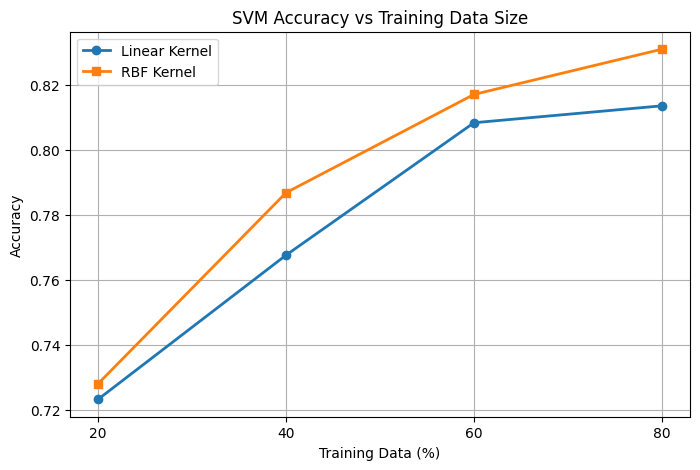

In [5]:
import matplotlib.pyplot as plt

train_sizes = [20, 40, 60, 80]

linear_acc = [0.7234, 0.7677, 0.8084, 0.8136]
rbf_acc    = [0.7282, 0.7869, 0.8171, 0.8310]

plt.figure(figsize=(8,5))

plt.plot(train_sizes, linear_acc,
         marker='o',
         linewidth=2,
         label='Linear Kernel')

plt.plot(train_sizes, rbf_acc,
         marker='s',
         linewidth=2,
         label='RBF Kernel')

plt.xlabel('Training Data (%)')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy vs Training Data Size')
plt.xticks(train_sizes)
plt.grid(True)
plt.legend()

plt.show()

In [42]:
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv.predict(pca.transform([img]))  # Predict using the trained SVM
        dec = {0: 'No Tumor',1: 'Pituitary Tumor',2: 'Glioma Tumor',3: 'Meningioma Tumor'}

        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

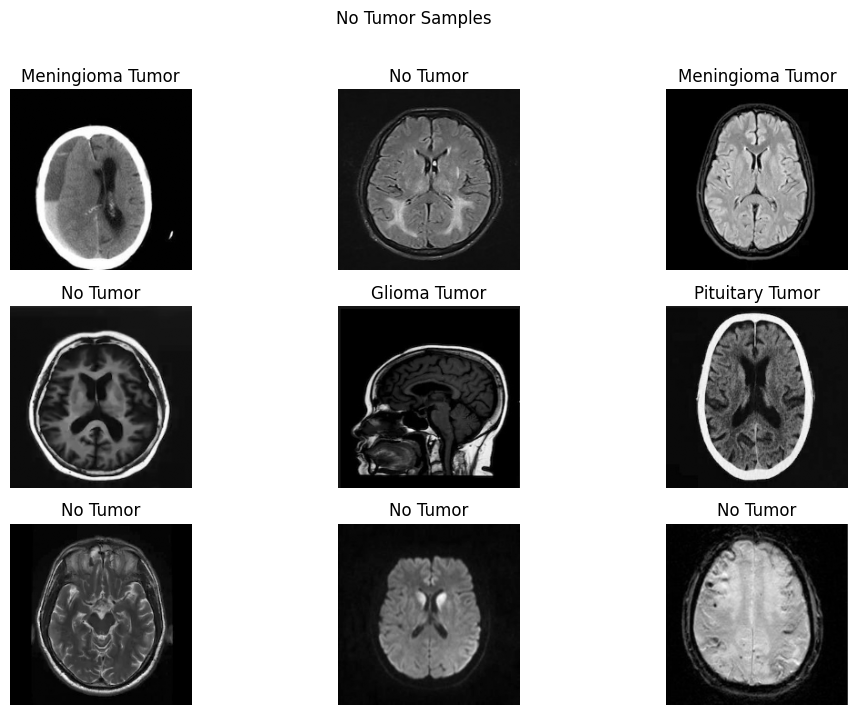

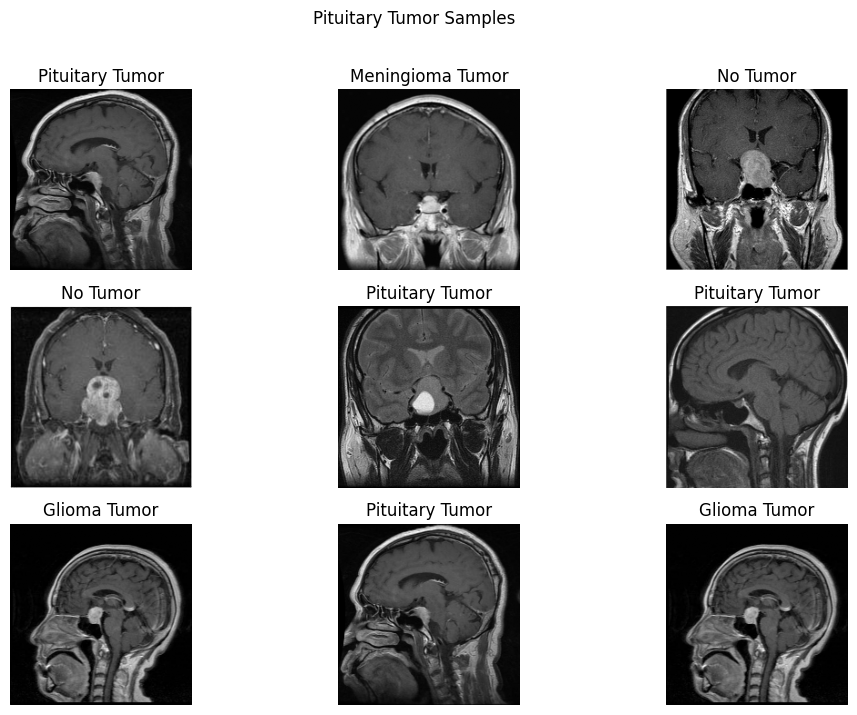

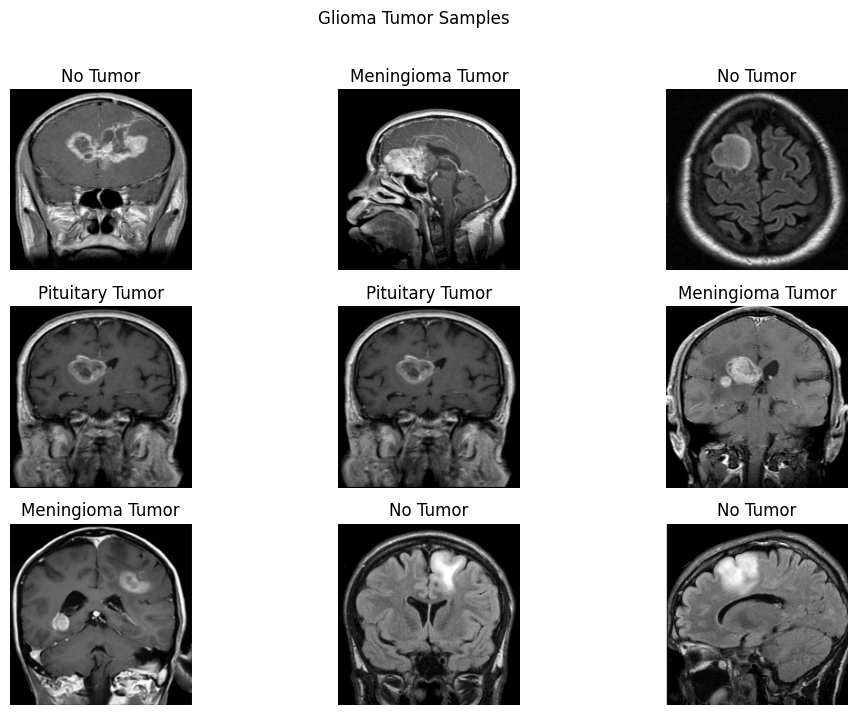

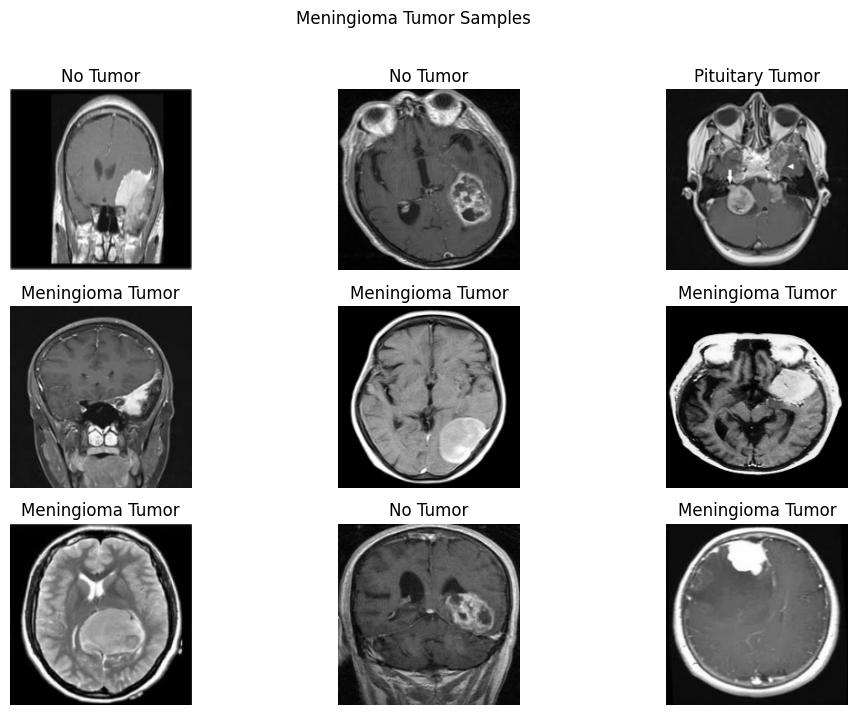

In [43]:
# Define class labels
dec = {0: 'No Tumor',1: 'Pituitary Tumor',2: 'Glioma Tumor',3: 'Meningioma Tumor'}

# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor','pituitary_tumor','glioma_tumor','meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = f"C:/Users/Tanishk/Desktop/Medical-Image-Classification/data/brain/Testing/{tumor_folder}"
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title)

In [44]:
# Count the occurrences of each tumor type
tumor_counts = {dec[label]: np.sum(Y == label) for label in classes.values()}

# Create a table to represent the tumor counts
table_data = {'Index': range(1, len(classes) + 1), 'Tumor Type': list(tumor_counts.keys()), 'Count': list(tumor_counts.values())}
tumor_table = pd.DataFrame(table_data)

# Apply styling to the table to add cell borders
styled_table = tumor_table.style.set_properties(**{'border': '3px solid black', 'text-align': 'center'})

# Display the styled tumor table
print("\033[1mTumor Type Counts:\033[0m") 
display(styled_table)

Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


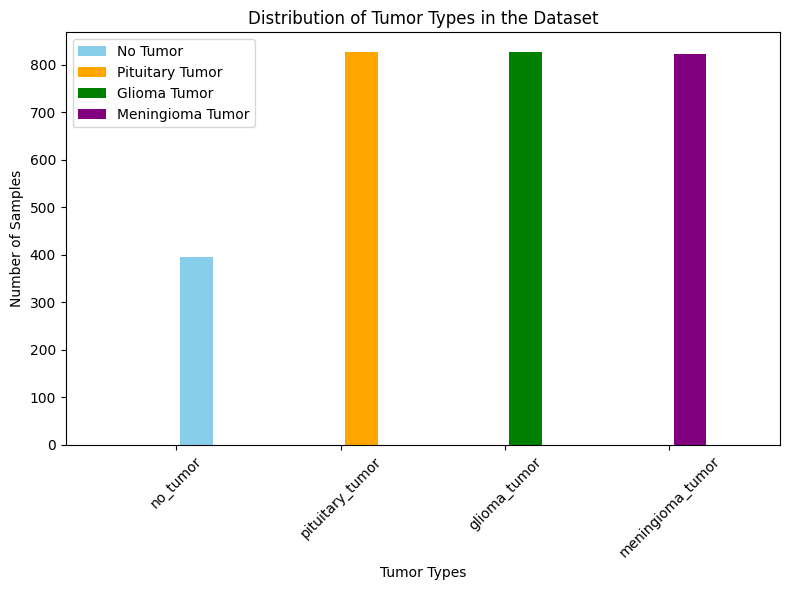

In [33]:
# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show() 